In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression,ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error,root_mean_squared_error,confusion_matrix,roc_auc_score,log_loss
from sklearn.metrics import f1_score,accuracy_score,recall_score,precision_score,classification_report
from tqdm import tqdm
import os
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler,PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
import datetime as dt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis,QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import BernoulliNB,GaussianNB
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer,make_column_selector
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [2]:
glass = pd.read_csv(r"../Datasets/Glass.csv")
glass

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,building_windows_float_processed
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,building_windows_float_processed
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,building_windows_float_processed
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,building_windows_float_processed
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,building_windows_float_processed
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,headlamps
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,headlamps
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,headlamps
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,headlamps


In [3]:
X = glass.drop('Type',axis=1)
y = glass['Type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=26, stratify=glass['Type'])

In [4]:
ohe=OneHotEncoder(sparse_output=False,drop="first").set_output(transform="pandas")
trans = ColumnTransformer(
    transformers=[("OHE", ohe,make_column_selector(dtype_include=object))],remainder="passthrough",
    verbose_feature_names_out=False).set_output(transform="pandas")

# X_trn_ohe = trans.fit_transform(X_train)
# X_tst_ohe = trans.transform(X_test)

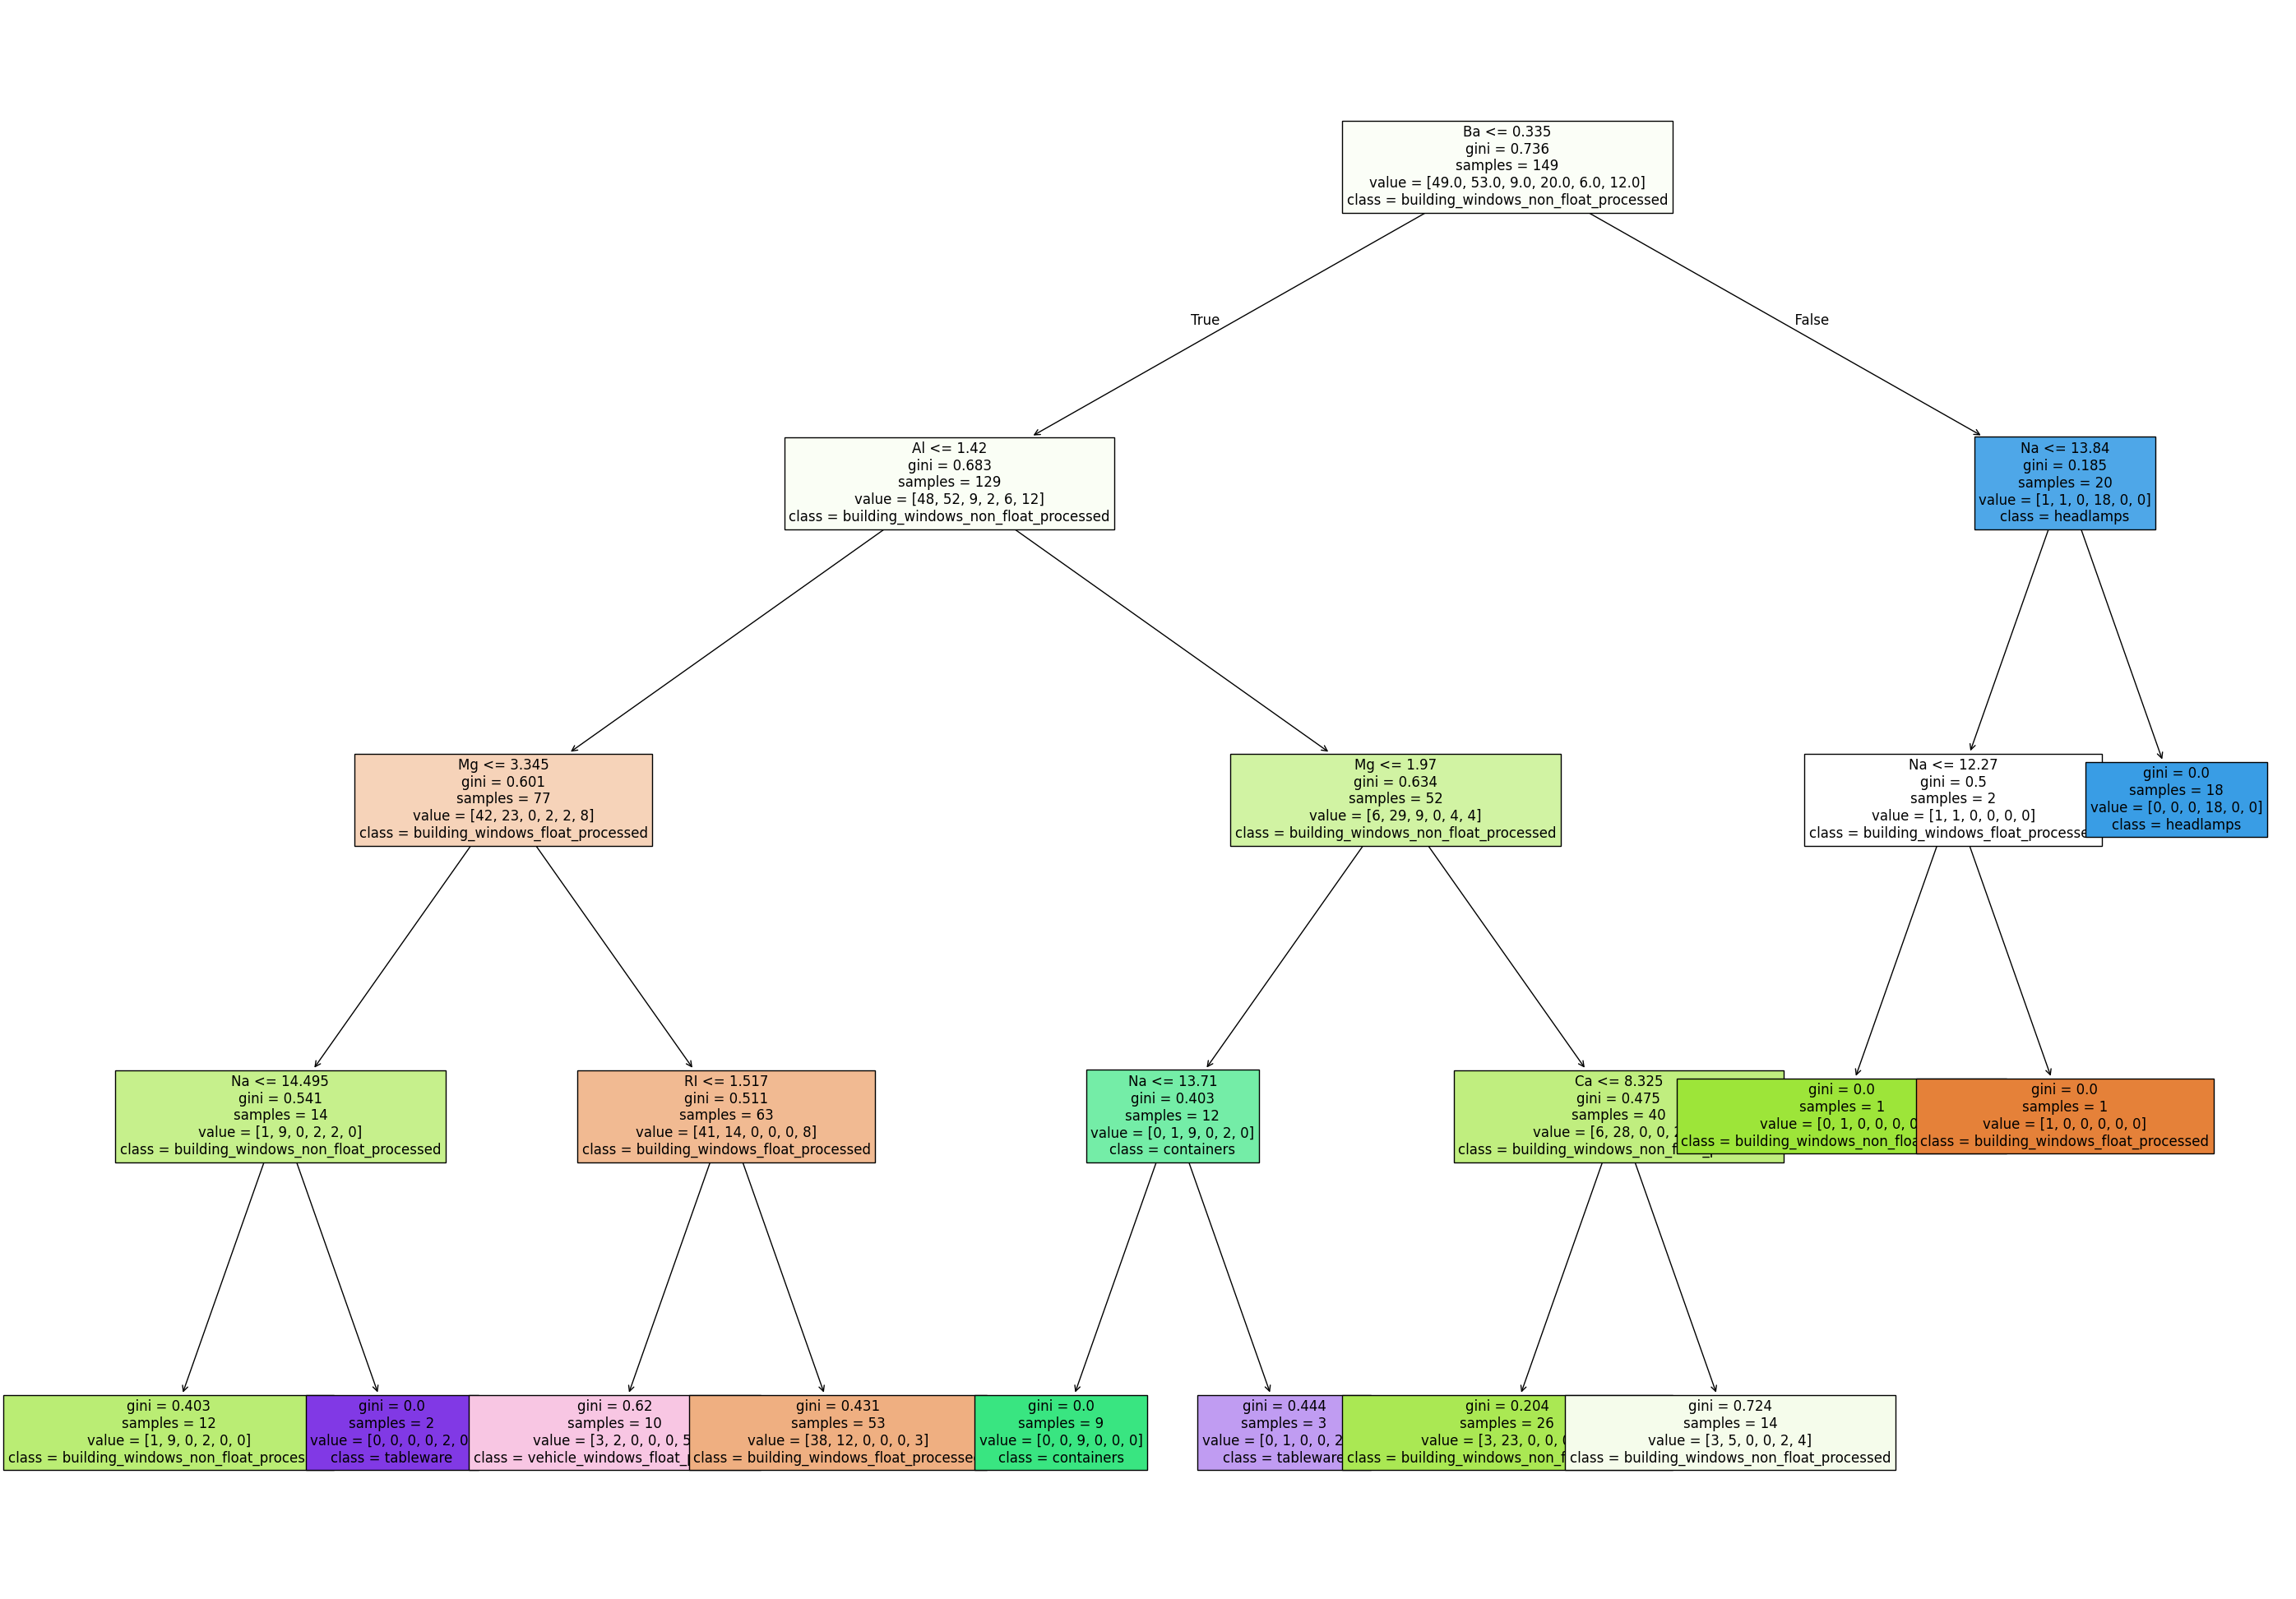

In [5]:
dtc = DecisionTreeClassifier(random_state=26,max_depth=4)
dtc.fit(X_train, y_train)

plt.figure(figsize=(35, 25))
plot_tree(dtc, 
          feature_names=list(X.columns), 
          class_names=dtc.classes_.tolist(), 
          filled=True, 
          fontsize=12)

plt.show()

In [9]:
depths=[1,2,3,5,None]
splits = [2,4,8,10,20,30,50,100]
leaves = [1,4,8,10,20,30,50,100]
scores=[]
for d in tqdm(depths):
    for s in splits:
        for l in leaves:
            dtc=DecisionTreeClassifier(random_state=26,max_depth=d,min_samples_split=s,min_samples_leaf=l)
            dtc.fit(X_train,y_train)
            y_pred_prob=dtc.predict_proba(X_test)
            y_pred=dtc.predict(X_test)
            scores.append([d,s,l,log_loss(y_test,y_pred_prob),accuracy_score(y_test,y_pred)])


df_scores = pd.DataFrame(scores, columns=['depths', 'splits', 'leaves', 'score', 'accuracy'])
df_scores.sort_values('score')

  0%|                                                                                            | 0/5 [00:00<?, ?it/s]

 20%|████████████████▊                                                                   | 1/5 [00:00<00:01,  2.17it/s]

 40%|█████████████████████████████████▌                                                  | 2/5 [00:00<00:01,  2.17it/s]

 60%|██████████████████████████████████████████████████▍                                 | 3/5 [00:01<00:00,  2.08it/s]

 80%|███████████████████████████████████████████████████████████████████▏                | 4/5 [00:01<00:00,  2.12it/s]

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.04it/s]

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.07it/s]

,depths,splits,leaves,score,accuracy
22,1.0,8,50,1.308049,0.400000
30,1.0,10,50,1.308049,0.400000
46,1.0,30,50,1.308049,0.400000
38,1.0,20,50,1.308049,0.400000
286,NaN,10,50,1.308049,0.400000
...,...,...,...,...,...
281,NaN,10,4,5.864406,0.707692
280,NaN,10,1,7.981790,0.661538
272,NaN,8,1,8.962651,0.692308
264,NaN,4,1,9.471269,0.707692


In [ ]:
bm.classes_.tolist()

In [ ]:

bm = DecisionTreeClassifier(  
                random_state=26,
                min_samples_leaf=30,
                min_samples_split=2,
                max_depth=2
            )


bm.fit(X,y)
plt.figure(figsize=(35, 15))

plot_tree(bm, feature_names = list(X.columns), class_names = bm.classes_.tolist(), filled = True, fontsize = 12)
plt.show()

df_imp = pd.DataFrame({'feature':X.columns,'importance':bm.feature_importances_})
plt.barh(df_imp['feature'],df_imp['importance'])
plt.title('Feature Importance Plot')
plt.show()